In [1]:
# import pandas as pd
# pd.read_csv('../working-vars/Y_gmm_20250717.csv', index_col=0)

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from importlib import reload

import mod_loading as loader
import figs_pcm 
import datetime 

In [3]:
# Import data
reload(loader)

[coreDS, coreINDEX, bgcDS, bgcINDEX, socat] = loader.import_data(type=['core', 'bgc', 'socat'])


In [4]:

# gmm_results 
[Y_gmm, allprobs, gmm_desc, coreDF] = loader.import_clustering_results() #Y_gmm
# gmm_desc = loader.import_clustering_results()[1] #'8pc_8class_500dbar'


## SOCAT

In [6]:
sepdict_7d

{'2014': None,
 '2015': None,
 '2016': None,
 '2017': None,
 '2018': None,
 '2019': None,
 '2020': None,
 '2021': None,
 '2022': None,
 '2023': None}

In [7]:
path = '/Volumes/crusoe-repo/data/socat/colocate-coreArgo/'

sepdict_7d = {key:None for key in [str(x) for x in range(2014,2024)]}

for x in os.listdir(path):
    if x.startswith('colocate_7d') & x.endswith('20260111.csv'):
        sepdict_7d[x[14:18]] = pd.read_csv(path+x, index_col=0)
        # print('Imported data for _7d window: ' + x)

sepstat_7d = pd.concat(sepdict_7d.values()).reset_index().drop(['level_0', 'index'], axis=1)
sepstat_7d.tail()


socat_df = sepstat_7d[sepstat_7d['latitude']<-35].reset_index()

In [37]:
# socat_df = socat.to_dataframe()
socat_df

,index,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,...,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class
0,0,-24.64215,-73.725900,341.6865,34.074,-1.2305,1.483947,NaN,341.700,NaN,...,2014-01-02 11:36:53,06AQ20131221_id0,-2062.0,7900378_id041,2014-01-09,-71.616580,-22.823985,6.720278,242.124951,2.0
1,1,-36.40135,-77.100350,365.8905,34.281,-1.7040,9.499502,NaN,365.900,NaN,...,2014-01-10 11:59:17,06AQ20131221_id0,-1087.0,7900378_id041,2014-01-09,-71.616580,-22.823985,1.295278,729.272575,2.0
2,2,-38.14620,-77.899100,275.3920,34.279,-1.4480,15.491701,NaN,275.400,NaN,...,2014-01-16 11:48:03,06AQ20131221_id0,-1168.0,7900378_id042,2014-01-19,-71.682778,-23.213771,2.700012,811.679788,2.0
3,3,-38.94590,-77.608000,375.1900,34.418,-1.7700,16.295197,NaN,375.200,NaN,...,2014-01-17 07:05:05,06AQ20131221_id0,-1009.0,7900378_id042,2014-01-19,-71.682778,-23.213771,1.896516,799.773551,2.0
4,4,-28.47890,-74.557400,298.7880,33.760,-1.3940,21.498843,NaN,298.800,NaN,...,2014-01-22 11:58:20,06AQ20131221_id1,-1639.0,7900378_id043,2014-01-29,-71.743994,-23.090656,6.695984,357.493891,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6283,6283,163.00795,-39.536095,370.5850,35.444,15.0160,3497.534375,372.560,370.135,NaN,...,2023-07-30 12:49:30,PAT520230724_id1,-3646.0,5905508_id071,2023-08-01,-39.699600,163.253800,2.079502,27.820801,5.0
6284,6284,154.23600,-37.704690,364.7370,35.543,16.0950,3498.604861,366.830,364.440,NaN,...,2023-07-31 14:31:00,PAT520230724_id1,-4523.0,5906152_id108,2023-07-30,-37.819290,152.754590,1.312465,130.846019,5.0
6285,6285,149.00550,-38.579580,366.4580,35.644,15.7330,3499.499306,368.570,366.130,NaN,...,2023-08-01 11:59:00,PAT520230724_id1,-2813.0,5905515_id120,2023-07-28,-38.527290,150.643725,3.723206,142.572572,5.0
6286,6286,177.57530,-37.193580,350.2155,35.146,15.6535,3574.664236,352.555,349.850,NaN,...,2023-10-15 15:56:30,PAT520231011_id1,-1709.0,5906421_id087,2023-10-15,-37.191630,178.572070,0.086331,88.292512,4.0


In [28]:
# === Separate socat data by class

# socat_df = sepstat_7d[sepstat_7d['latitude']<-35].reset_index()
for ind in range(len(socat_df)):
    try:
        socat_df.loc[ind,  'class'] = int(Y_gmm.loc[socat_df.loc[ind, 'nearest_profid'], 'class'])
    except:
        socat_df.loc[ind,  'class'] = None

# Account for missing classes by looking at neighboring observations in the same cruise
# If same, then fill in the missing class
missingClasses = socat_df[socat_df['class'].isna()] #.reset_index()
Replaced = []
notReplaced = []
for ind, row in missingClasses.iterrows():
    obs_ID = row.expoID
    cruise_num = str(obs_ID).split('_')[0]
    obs_num = int(str(obs_ID).split('id')[1])
    try:
        class_before = socat_df[socat_df['expoID'] == (cruise_num + '_id' + str(obs_num -1))]['class'].values[0]
        class_after  = socat_df[socat_df['expoID'] == (cruise_num + '_id' + str(obs_num +1))]['class'].values[0]
        if class_before == class_after:
            socat_df.loc[socat_df['expoID'] == obs_ID, 'class'] = class_before
            Replaced.append(obs_ID)
    except:
        notReplaced.append(obs_ID)


# Make dictionary
socat_classes = {k:None for k in range(8)}
for ind in range(8):
    socat_classes[ind] = socat_df[socat_df['class']==ind]

In [38]:
socat_df[~socat_df['class'].isna()]

,index,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,...,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class
0,0,-24.64215,-73.725900,341.6865,34.074,-1.2305,1.483947,NaN,341.700,NaN,...,2014-01-02 11:36:53,06AQ20131221_id0,-2062.0,7900378_id041,2014-01-09,-71.616580,-22.823985,6.720278,242.124951,2.0
1,1,-36.40135,-77.100350,365.8905,34.281,-1.7040,9.499502,NaN,365.900,NaN,...,2014-01-10 11:59:17,06AQ20131221_id0,-1087.0,7900378_id041,2014-01-09,-71.616580,-22.823985,1.295278,729.272575,2.0
2,2,-38.14620,-77.899100,275.3920,34.279,-1.4480,15.491701,NaN,275.400,NaN,...,2014-01-16 11:48:03,06AQ20131221_id0,-1168.0,7900378_id042,2014-01-19,-71.682778,-23.213771,2.700012,811.679788,2.0
3,3,-38.94590,-77.608000,375.1900,34.418,-1.7700,16.295197,NaN,375.200,NaN,...,2014-01-17 07:05:05,06AQ20131221_id0,-1009.0,7900378_id042,2014-01-19,-71.682778,-23.213771,1.896516,799.773551,2.0
4,4,-28.47890,-74.557400,298.7880,33.760,-1.3940,21.498843,NaN,298.800,NaN,...,2014-01-22 11:58:20,06AQ20131221_id1,-1639.0,7900378_id043,2014-01-29,-71.743994,-23.090656,6.695984,357.493891,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6283,6283,163.00795,-39.536095,370.5850,35.444,15.0160,3497.534375,372.560,370.135,NaN,...,2023-07-30 12:49:30,PAT520230724_id1,-3646.0,5905508_id071,2023-08-01,-39.699600,163.253800,2.079502,27.820801,5.0
6284,6284,154.23600,-37.704690,364.7370,35.543,16.0950,3498.604861,366.830,364.440,NaN,...,2023-07-31 14:31:00,PAT520230724_id1,-4523.0,5906152_id108,2023-07-30,-37.819290,152.754590,1.312465,130.846019,5.0
6285,6285,149.00550,-38.579580,366.4580,35.644,15.7330,3499.499306,368.570,366.130,NaN,...,2023-08-01 11:59:00,PAT520230724_id1,-2813.0,5905515_id120,2023-07-28,-38.527290,150.643725,3.723206,142.572572,5.0
6286,6286,177.57530,-37.193580,350.2155,35.146,15.6535,3574.664236,352.555,349.850,NaN,...,2023-10-15 15:56:30,PAT520231011_id1,-1709.0,5906421_id087,2023-10-15,-37.191630,178.572070,0.086331,88.292512,4.0


In [30]:
xr.Dataset.from_dataframe(socat_classes[0])

<xarray.Dataset>
Dimensions:            (index: 346)
Coordinates:
  * index              (index) int64 19 20 21 25 26 ... 6254 6262 6263 6268 6277
Data variables: (12/23)
    longitude          (index) float64 14.26 15.03 15.81 ... 6.752 175.1 175.4
    latitude           (index) float64 -44.27 -42.42 -40.47 ... -41.99 -41.77
    fco2rec            (index) float64 349.3 343.6 347.5 ... 388.3 372.9 382.2
    sal                (index) float64 34.3 34.52 35.39 ... 34.7 34.83 34.59
    sst                (index) float64 12.25 13.34 18.18 ... 15.9 15.93 18.93
    yearday            (index) float64 58.5 59.52 60.51 ... 3.368e+03 3.338e+03
    ...                 ...
    prof_datetime      (index) object '2014-03-04' '2014-03-07' ... '2023-02-17'
    prof_lat           (index) float64 -44.43 -42.84 -40.82 ... -42.1 -42.3
    prof_lon           (index) float64 12.96 15.44 15.27 ... 6.951 176.3 175.8
    yd_sep             (index) float64 4.321 6.308 1.335 ... 5.959 1.598 4.213
    km_sep             (index) float64 104.9 57.54 60.92 ... 17.25 94.36 66.93
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [15]:
socat_df

,index,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,...,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class
0,0,-24.64215,-73.725900,341.6865,34.074,-1.2305,1.483947,NaN,341.700,NaN,...,2014-01-02 11:36:53,06AQ20131221_id0,-2062.0,7900378_id041,2014-01-09,-71.616580,-22.823985,6.720278,242.124951,2.0
1,1,-36.40135,-77.100350,365.8905,34.281,-1.7040,9.499502,NaN,365.900,NaN,...,2014-01-10 11:59:17,06AQ20131221_id0,-1087.0,7900378_id041,2014-01-09,-71.616580,-22.823985,1.295278,729.272575,2.0
2,2,-38.14620,-77.899100,275.3920,34.279,-1.4480,15.491701,NaN,275.400,NaN,...,2014-01-16 11:48:03,06AQ20131221_id0,-1168.0,7900378_id042,2014-01-19,-71.682778,-23.213771,2.700012,811.679788,2.0
3,3,-38.94590,-77.608000,375.1900,34.418,-1.7700,16.295197,NaN,375.200,NaN,...,2014-01-17 07:05:05,06AQ20131221_id0,-1009.0,7900378_id042,2014-01-19,-71.682778,-23.213771,1.896516,799.773551,2.0
4,4,-28.47890,-74.557400,298.7880,33.760,-1.3940,21.498843,NaN,298.800,NaN,...,2014-01-22 11:58:20,06AQ20131221_id1,-1639.0,7900378_id043,2014-01-29,-71.743994,-23.090656,6.695984,357.493891,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6283,6283,163.00795,-39.536095,370.5850,35.444,15.0160,3497.534375,372.560,370.135,NaN,...,2023-07-30 12:49:30,PAT520230724_id1,-3646.0,5905508_id071,2023-08-01,-39.699600,163.253800,2.079502,27.820801,5.0
6284,6284,154.23600,-37.704690,364.7370,35.543,16.0950,3498.604861,366.830,364.440,NaN,...,2023-07-31 14:31:00,PAT520230724_id1,-4523.0,5906152_id108,2023-07-30,-37.819290,152.754590,1.312465,130.846019,5.0
6285,6285,149.00550,-38.579580,366.4580,35.644,15.7330,3499.499306,368.570,366.130,NaN,...,2023-08-01 11:59:00,PAT520230724_id1,-2813.0,5905515_id120,2023-07-28,-38.527290,150.643725,3.723206,142.572572,5.0
6286,6286,177.57530,-37.193580,350.2155,35.146,15.6535,3574.664236,352.555,349.850,NaN,...,2023-10-15 15:56:30,PAT520231011_id1,-1709.0,5906421_id087,2023-10-15,-37.191630,178.572070,0.086331,88.292512,4.0


In [43]:
# Good version, Aug 5 2025 
list = []
for class_id, ds in socat_classes.items():
    # Create a new coordinate 'class' for each profile
    temp_ds = (xr.Dataset.from_dataframe(socat_classes[class_id].set_index('index'))
    )
    list.append(temp_ds.assign_coords(cluster = temp_ds['class'].astype(int)+1))

# Merge all classes along profid
clustered_socat_ds = xr.concat(list, dim="index")
clustered_socat_ds

<xarray.Dataset>
Dimensions:            (index: 6088)
Coordinates:
  * index              (index) int64 19 20 21 25 26 ... 6040 6041 6042 6208 6209
    cluster            (index) int64 1 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8 8 8
Data variables: (12/23)
    longitude          (index) float64 14.26 15.03 15.81 ... -97.53 52.46 52.27
    latitude           (index) float64 -44.27 -42.42 -40.47 ... -43.8 -45.0
    fco2rec            (index) float64 349.3 343.6 347.5 ... 439.1 404.7 419.7
    sal                (index) float64 34.3 34.52 35.39 ... 33.75 33.68 33.69
    sst                (index) float64 12.25 13.34 18.18 ... 10.66 13.83 9.414
    yearday            (index) float64 58.5 59.52 60.51 ... 3.315e+03 3.316e+03
    ...                 ...
    prof_datetime      (index) object '2014-03-04' '2014-03-07' ... '2023-01-28'
    prof_lat           (index) float64 -44.43 -42.84 -40.82 ... -44.22 -44.22
    prof_lon           (index) float64 12.96 15.44 15.27 ... -98.32 51.99 51.99
    yd_sep             (index) float64 4.321 6.308 1.335 ... 1.032 1.238 2.067
    km_sep             (index) float64 104.9 57.54 60.92 ... 158.4 59.87 89.96
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0

In [44]:
save = True
datetag = datetime.datetime.now().strftime('%Y%m%d')
if save:
    clustered_socat_ds.to_netcdf('../working-vars/pcm/clustered_socat_1d_acc' + datetag + '.nc')

In [45]:
for ind in range(8):
    print(f'Class {ind+1}: {len(socat_classes[ind].index.values)}')

Class 1: 346
Class 2: 852
Class 3: 1189
Class 4: 508
Class 5: 1253
Class 6: 213
Class 7: 1639
Class 8: 88


<GeoAxes: >

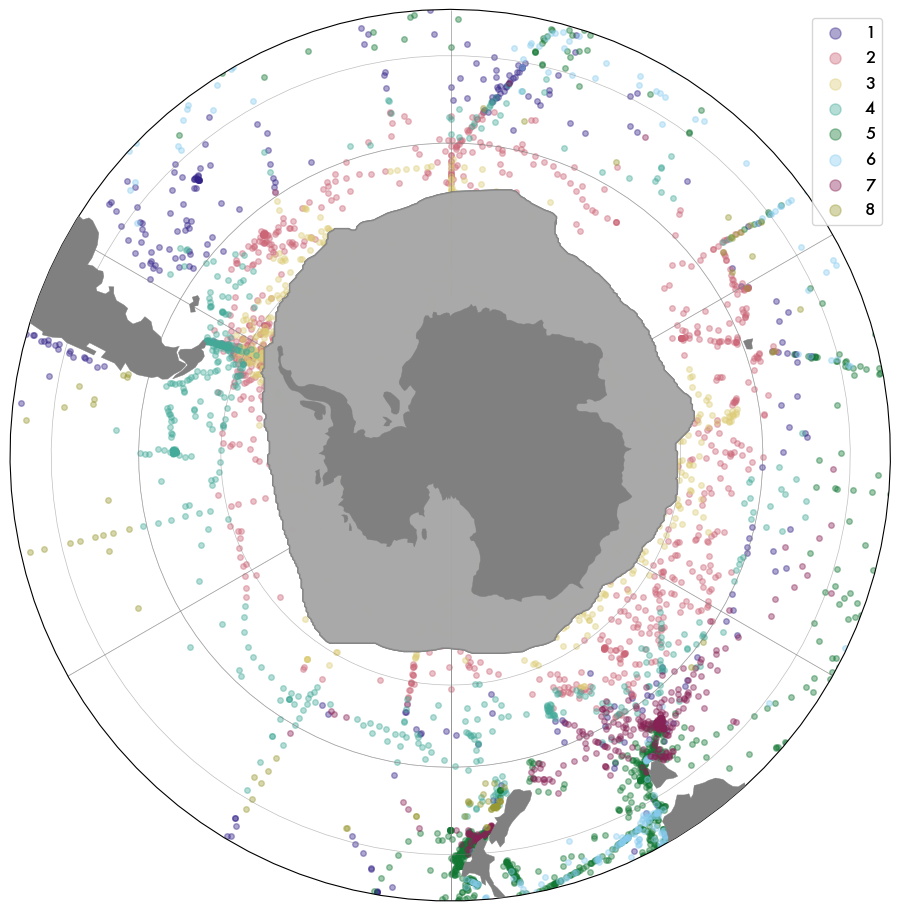

In [36]:
reload(figs_pcm)

# To plot all classes on one plot
figs_pcm.sopolar_classes(socat_classes, inds=range(8), figsize=(9,9), dotsize=16, markerscale=2)

# Classify bgcArgo data and create new xr Dataset



In [4]:
bgcDS
# bgcINDEX.sel(profid=bgcDS.profid.values)

<xarray.Dataset>
Dimensions:      (profid: 11749, pressure: 197)
Coordinates:
  * profid       (profid) object '2903453_id001' ... '6903026_id097'
  * pressure     (pressure) int64 0 5 10 15 20 25 30 ... 955 960 965 970 975 980
    yearday      (profid, pressure) float64 ...
    latitude     (profid, pressure) float64 ...
    longitude    (profid, pressure) float64 ...
    wmoid        (profid, pressure) float64 ...
    datetime     (profid, pressure) datetime64[ns] ...
Data variables:
    CT           (profid, pressure) float64 ...
    SA           (profid, pressure) float64 ...
    sigma0       (profid, pressure) float64 ...
    spice        (profid, pressure) float64 ...
    temperature  (profid, pressure) float64 ...
    salinity     (profid, pressure) float64 ...
    pH           (profid, pressure) float64 ...
    oxygen       (profid, pressure) float64 ...
Attributes:
    title:            BGC float profiles with valid data, interpolated to n=2...
    pressure_levels:  Pressure levels in dbar: [0, 5, 10, 15, 20, 25, 30, 35,...
    source:           Argopy, expert mode
    date:             20250729

In [5]:
# === Separate bgc data by class
bgc_df = bgcINDEX.to_dataframe()

for ind in bgc_df.index:
    try:
        bgc_df.loc[ind,  'class'] = int(gmm_results.loc[ind, 'class'])
    except:
        bgc_df.loc[ind,  'class'] = None

# Make dictionary
bgc_classes = {k:None for k in range(8)}
for ind in range(8):
    # bgc_classes[ind] = bgc_df[bgc_df['class']==ind]
    bgc_classes[ind] = bgcDS.sel({'profid':[x for x in bgc_df[bgc_df['class']==ind].index]})

In [6]:
list = []
for class_id, ds in bgc_classes.items():
    # Create a new coordinate 'class' for each profile
    ds_with_class = ds.assign_coords(cluster = (ds.yearday * 0 + class_id + 1))
    list.append(ds_with_class)

# Merge all classes along profid
merged_ds = xr.concat(list, dim="profid")

merged_ds.assign_attrs({'gmm_run_params': gmm_desc})

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/p

<xarray.Dataset>
Dimensions:      (profid: 11346, pressure: 197)
Coordinates:
  * profid       (profid) object '2903456_id018' ... '5906567_id015'
  * pressure     (pressure) int64 0 5 10 15 20 25 30 ... 955 960 965 970 975 980
    yearday      (profid, pressure) float64 3.622e+03 3.622e+03 ... 3.391e+03
    latitude     (profid, pressure) float64 -54.48 -54.48 ... -44.81 -44.81
    longitude    (profid, pressure) float64 -143.3 -143.3 ... -165.0 -165.0
    wmoid        (profid, pressure) float64 2.903e+06 2.903e+06 ... 5.907e+06
    datetime     (profid, pressure) datetime64[ns] 2023-12-01T21:53:59 ... 20...
    cluster      (profid, pressure) float64 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Data variables:
    CT           (profid, pressure) float64 6.84 6.84 6.839 ... 6.116 6.086
    SA           (profid, pressure) float64 34.08 34.08 34.08 ... 34.51 34.51
    sigma0       (profid, pressure) float64 26.59 26.59 26.59 ... 27.03 27.03
    spice        (profid, pressure) float64 -0.04522 -0.04522 ... 0.1647 0.1603
    temperature  (profid, pressure) float64 6.833 6.833 6.833 ... 6.205 6.175
    salinity     (profid, pressure) float64 33.92 33.92 33.92 ... 34.35 34.35
    pH           (profid, pressure) float64 8.006 8.006 8.005 ... 7.887 7.887
    oxygen       (profid, pressure) float64 301.1 301.1 301.0 ... 220.9 220.1
Attributes:
    title:            BGC float profiles with valid data, interpolated to n=2...
    pressure_levels:  Pressure levels in dbar: [0, 5, 10, 15, 20, 25, 30, 35,...
    source:           Argopy, expert mode
    date:             20250729
    gmm_run_params:   8pc_8class_500dbar

In [ ]:
# Save new Dataset with cluster assignments
save=False
if save:
    datetag = datetime.datetime.now().strftime('%Y%m%d')
    merged_ds.to_netcdf('../working-vars/pcm/clustered_bgcArgo_acc' + datetag + '.nc')
    print('Saved to ' + '../working-vars/pcm/clustered_bgcArgo_acc' + datetag + '.nc')

Saved to ../working-vars/pcm/clustered_bgcArgo_acc20251201.nc


## Plots of bgc Argo data

In [17]:
from matplotlib import pyplot as plt

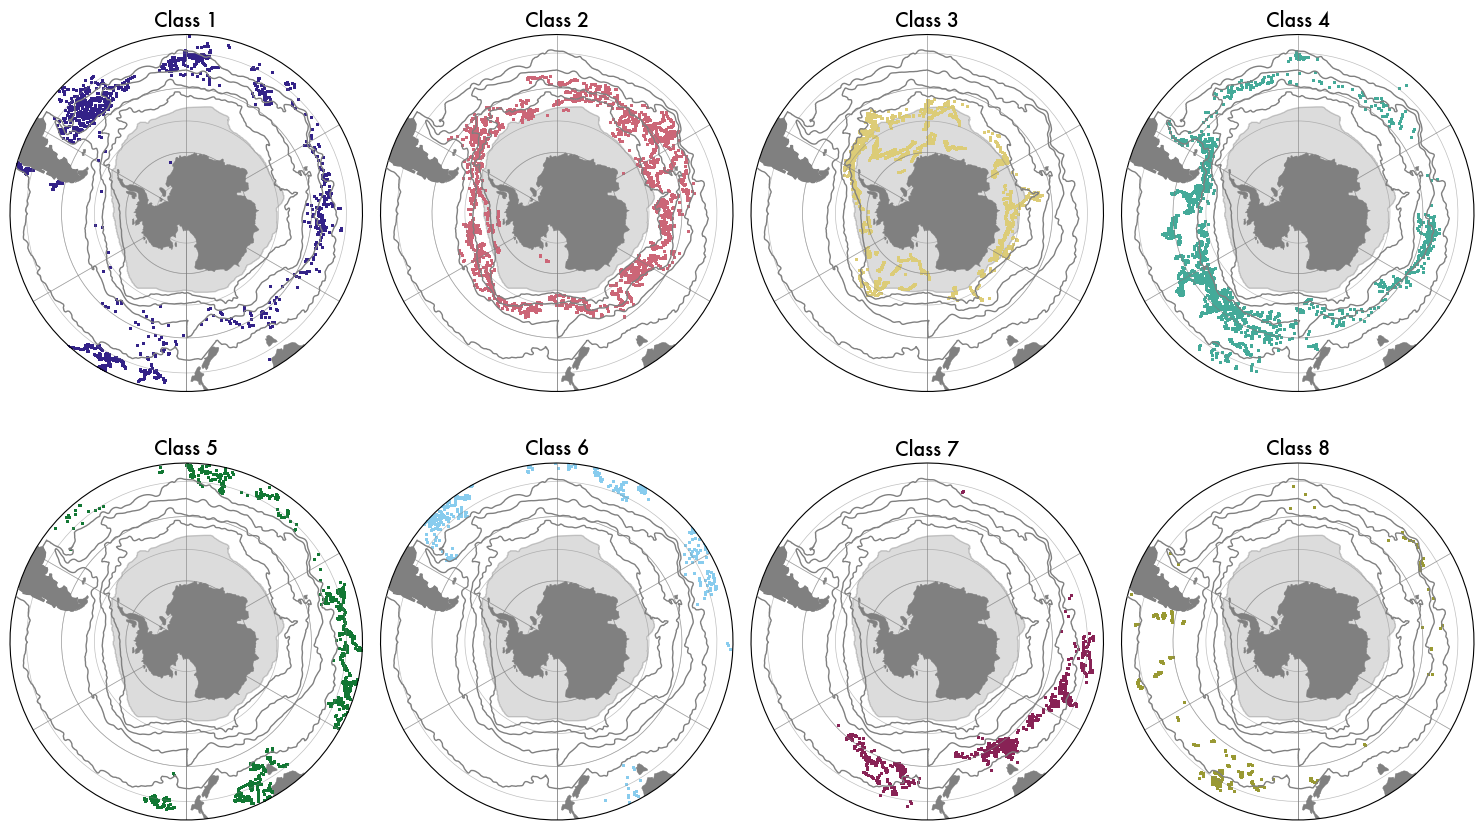

In [8]:
reload(figs_pcm)
figs_pcm.sopolar_classes_paneled(bgc_classes, figsize=(9,9))

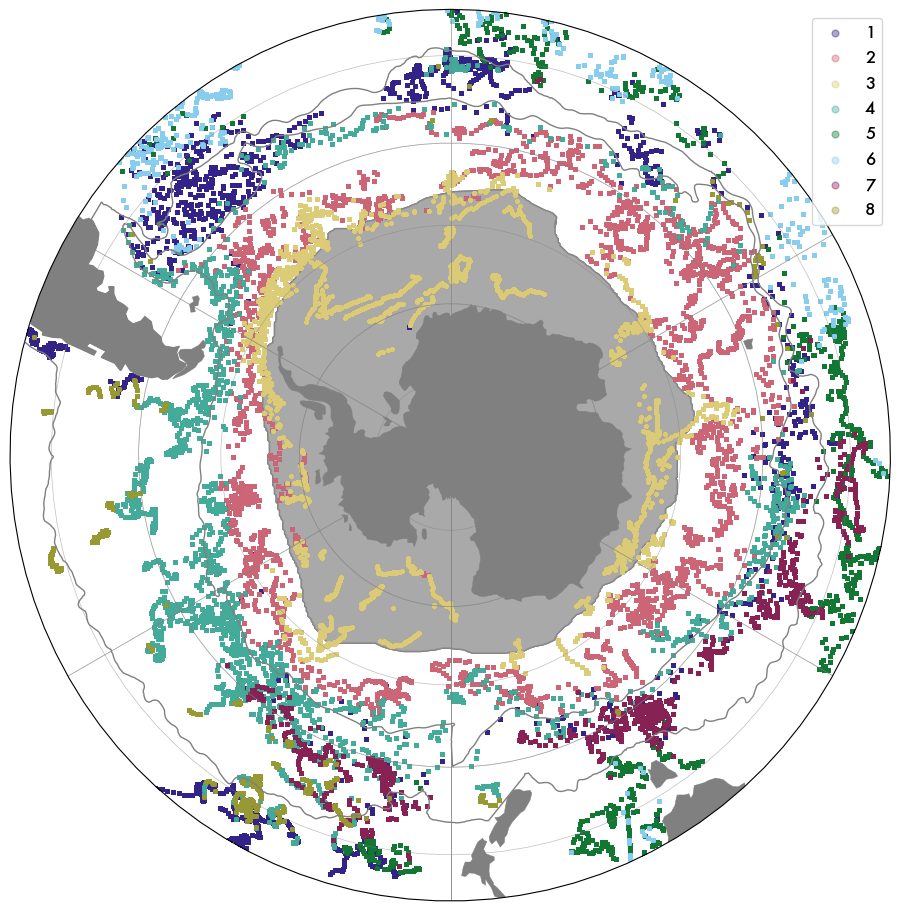

In [ ]:
reload(figs_pcm)

# To plot all classes on one plot
ax = figs_pcm.sopolar_classes(bgc_classes, inds=range(8), 
                         figsize=(9,9), 
                         dotsize=6, markerscale=2)

# figs_pcm.sopolar_classes(socat_classes, inds=range(8), 
#                          ax=ax, figsize=(9,9), 
#                          dotsize=6, markerscale=2, legend=False)

# ax.set_title('BGC and SOCAT data')

import mod_southpolarplot as sopo
sopo.add_frontlines(ax, types=['saf', 'stf'])

In [19]:
# Compare number of training obs for each class
nobs_table = pd.DataFrame(index = range(8))
for ind in range(8):
    nobs_table.loc[ind, 'socat'] = int(len(socat_classes[ind].index.values))
    nobs_table.loc[ind, 'bgc'] = int(len(bgc_classes[ind].profid.values))
    
nobs_table['total_training'] = nobs_table['socat'] + nobs_table['bgc']
nobs_table.index=range(1,9)
nobs_table

,socat,bgc,total_training
1,2354.0,1415.0,3769.0
2,5965.0,2502.0,8467.0
3,8190.0,2787.0,10977.0
4,3644.0,2063.0,5707.0
5,8286.0,936.0,9222.0
6,1622.0,366.0,1988.0
7,11852.0,885.0,12737.0
8,546.0,392.0,938.0


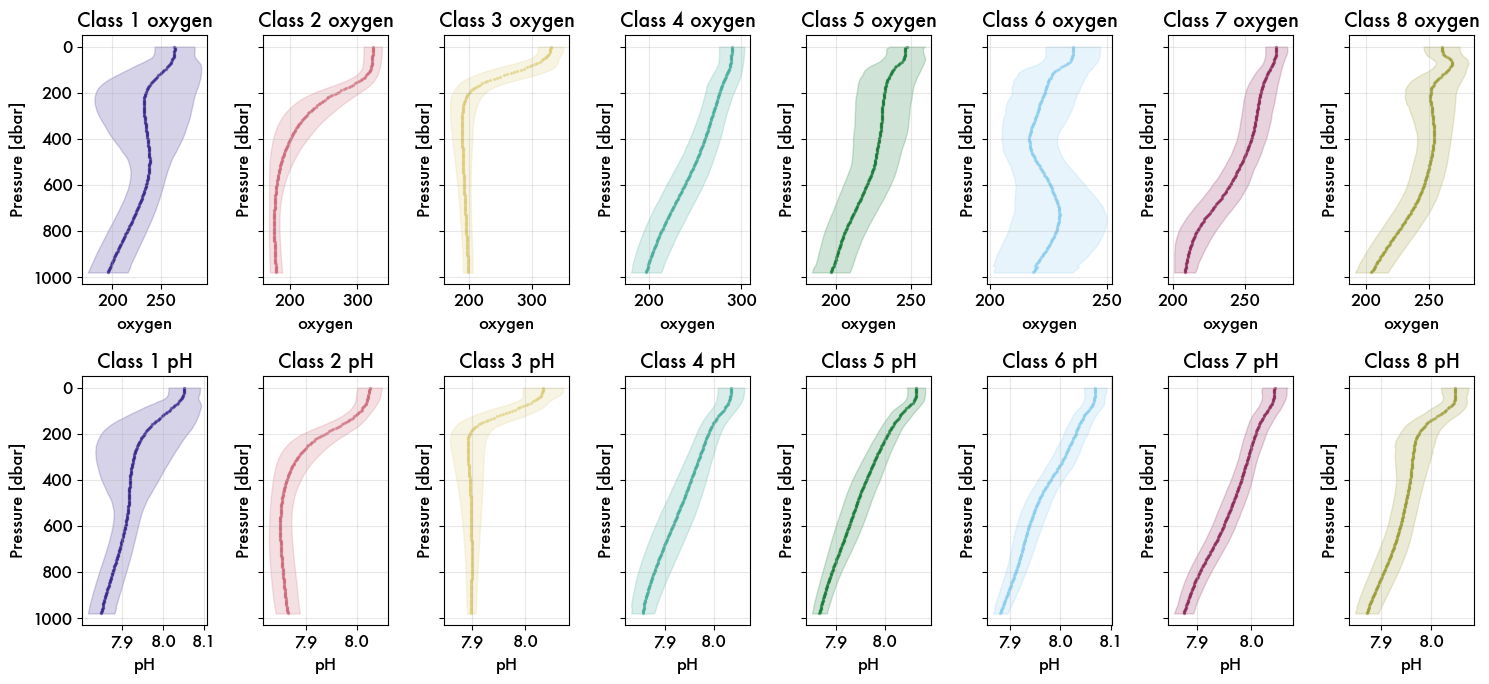

In [20]:
reload(figs_pcm)
figs_pcm.mean_tracer_profiles_paneled(bgc_classes, vars = ['oxygen', 'pH'],
                                 figsize = (15,7))